# Consumer Segmentation

## Objective

Identify behaviorally distinct and commercially interpretable consumer groups using K-Means.

### Initial segmentation feature set

Exactly six behavioral dimensions are evaluated:

- `recency_days`
- `purchase_frequency`
- `total_spend`
- `average_basket_value`
- `category_diversity`
- `promotion_purchase_share`

Demographic variables are not used for clustering.

### Modelling principles

- Eligibility is evaluated before modelling.
- Missing values are investigated rather than arbitrarily imputed.
- Extreme tails are reviewed before any capping decision.
- Transformations are applied only when analytically justified.
- `promotion_purchase_share` is not log-transformed.
- Clustering uses scaled/transformed features.
- Business-facing profiles remain on original units.
- K-Means candidates will initially be evaluated for `k = 3, 4, 5`.
- Segment names will be assigned only after behavioral profiles are observed.


## 1. Environment and database connection

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

ENV_PATH = PROJECT_ROOT / ".env"

if not ENV_PATH.exists():
    raise FileNotFoundError(
        f"Missing environment file: {ENV_PATH}"
    )

def load_env_file(path: Path) -> None:
    for raw_line in path.read_text().splitlines():
        line = raw_line.strip()

        if (
            not line
            or line.startswith("#")
            or "=" not in line
        ):
            continue

        key, value = line.split("=", 1)

        key = key.strip()
        value = value.strip()

        if (
            len(value) >= 2
            and value[0] == value[-1]
            and value[0] in {"'", '"'}
        ):
            value = value[1:-1]

        os.environ.setdefault(key, value)

load_env_file(ENV_PATH)

required_env = [
    "DB_HOST",
    "DB_PORT",
    "DB_NAME",
    "DB_USER",
    "DB_PASSWORD",
]

missing_env = [
    key
    for key in required_env
    if not os.getenv(key)
]

if missing_env:
    raise RuntimeError(
        f"Missing required environment variables: "
        f"{missing_env}"
    )

database_url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.environ["DB_USER"],
    password=os.environ["DB_PASSWORD"],
    host=os.environ["DB_HOST"],
    port=int(os.environ["DB_PORT"]),
    database=os.environ["DB_NAME"],
)

engine = create_engine(database_url)

with engine.connect() as connection:
    database_check = connection.execute(
        text(
            '''
            SELECT
                current_database() AS database_name,
                current_user AS database_user
            '''
        )
    ).mappings().one()

print(
    "Database connection: OK | "
    f"database={database_check['database_name']} | "
    f"user={database_check['database_user']}"
)


Database connection: OK | database=fmcg_consumer_growth | user=fmcg_analytics


## 2. Load segmentation inputs

`analytics.customer_metrics` provides the six clustering features and the original-scale measures needed for later profiling.

Category-level data is loaded separately for later segment interpretation, but is not used as additional K-Means input.


In [2]:
customer_metrics = pd.read_sql_query(
    text(
        '''
        SELECT *
        FROM analytics.customer_metrics
        ORDER BY customer_id
        '''
    ),
    engine,
)

customer_category_metrics = pd.read_sql_query(
    text(
        '''
        SELECT *
        FROM analytics.customer_category_metrics
        ORDER BY customer_id, category_rank
        '''
    ),
    engine,
)

SEGMENT_FEATURES = [
    "recency_days",
    "purchase_frequency",
    "total_spend",
    "average_basket_value",
    "category_diversity",
    "promotion_purchase_share",
]

numeric_columns = list(
    dict.fromkeys(
        SEGMENT_FEATURES
        + [
            "total_transactions",
            "promotion_spend_share",
            "average_items_per_basket",
        ]
    )
)

for column in numeric_columns:
    customer_metrics[column] = pd.to_numeric(
        customer_metrics[column],
        errors="coerce",
    )

print(
    f"Customer rows loaded: "
    f"{len(customer_metrics):,}"
)

print(
    f"Category rows loaded: "
    f"{len(customer_category_metrics):,}"
)


Customer rows loaded: 2,500
Category rows loaded: 286,548


## 3. Segmentation Eligibility

A customer is eligible when:

- `customer_id` is valid;
- at least one valid basket exists;
- `total_spend > 0`;
- all six required segmentation features are derivable.

No behavioral feature is imputed merely to preserve a customer in the clustering population.


In [3]:
feature_missing = (
    customer_metrics[
        SEGMENT_FEATURES
    ]
    .isna()
    .any(axis=1)
)

eligibility_mask = (
    customer_metrics["customer_id"].notna()
    & (customer_metrics["total_transactions"] > 0)
    & (customer_metrics["total_spend"] > 0)
    & ~feature_missing
)

eligible_customers = (
    customer_metrics.loc[
        eligibility_mask
    ]
    .copy()
    .reset_index(drop=True)
)

excluded_customers = (
    customer_metrics.loc[
        ~eligibility_mask
    ]
    .copy()
    .reset_index(drop=True)
)

eligibility_summary = pd.DataFrame(
    {
        "metric": [
            "Total customers",
            "Eligible customers",
            "Excluded customers",
            "Customers with missing features",
            "Customers with non-positive spend",
            "Customers without valid baskets",
        ],
        "value": [
            len(customer_metrics),
            len(eligible_customers),
            len(excluded_customers),
            int(feature_missing.sum()),
            int(
                (
                    customer_metrics["total_spend"]
                    <= 0
                ).sum()
            ),
            int(
                (
                    customer_metrics[
                        "total_transactions"
                    ]
                    <= 0
                ).sum()
            ),
        ],
    }
)

assert (
    eligible_customers["customer_id"]
    .duplicated()
    .sum()
    == 0
)

assert (
    eligible_customers[
        SEGMENT_FEATURES
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

print("SEGMENTATION ELIGIBILITY")

for row in eligibility_summary.itertuples(
    index=False
):
    print(
        f"{row.metric}: "
        f"{int(row.value)}"
    )


SEGMENTATION ELIGIBILITY
Total customers: 2500
Eligible customers: 2500
Excluded customers: 0
Customers with missing features: 0
Customers with non-positive spend: 0
Customers without valid baskets: 0


## 4. Feature Distribution Diagnostics

Before selecting preprocessing rules, inspect:

- percentile ranges;
- raw skewness;
- skewness after `log1p`;
- 1st/99th percentile tails;
- how far the observed maximum extends beyond P99.

The diagnostic table informs preprocessing decisions; it does not automatically trigger capping or transformation.


In [4]:
diagnostic_rows = []

for feature in SEGMENT_FEATURES:
    series = (
        eligible_customers[feature]
        .astype(float)
    )

    q01 = series.quantile(0.01)
    q05 = series.quantile(0.05)
    q25 = series.quantile(0.25)
    q50 = series.quantile(0.50)
    q75 = series.quantile(0.75)
    q95 = series.quantile(0.95)
    q99 = series.quantile(0.99)

    raw_skew = series.skew()

    if (
        feature
        != "promotion_purchase_share"
        and (series >= 0).all()
    ):
        log_skew = (
            np.log1p(series)
            .skew()
        )
    else:
        log_skew = np.nan

    central_range = q99 - q01

    if central_range > 0:
        range_expansion = (
            (series.max() - series.min())
            / central_range
        )
    else:
        range_expansion = np.nan

    diagnostic_rows.append(
        {
            "feature": feature,
            "minimum": series.min(),
            "p01": q01,
            "p05": q05,
            "p25": q25,
            "median": q50,
            "p75": q75,
            "p95": q95,
            "p99": q99,
            "maximum": series.max(),
            "raw_skew": raw_skew,
            "log1p_skew": log_skew,
            "below_p01_count": int(
                (series < q01).sum()
            ),
            "above_p99_count": int(
                (series > q99).sum()
            ),
            "range_expansion_vs_p01_p99": (
                range_expansion
            ),
        }
    )

feature_diagnostics = pd.DataFrame(
    diagnostic_rows
)

display(feature_diagnostics)


,feature,minimum,p01,p05,p25,median,p75,p95,p99,maximum,raw_skew,log1p_skew,below_p01_count,above_p99_count,range_expansion_vs_p01_p99
0,recency_days,0.0000,0.0000,0.0000,1.0000,6.0000,20.0000,117.0500,317.0500,657.0000,5.5747,0.4777,0,25,2.0722
1,purchase_frequency,1.0000,1.0762,1.4371,2.4444,3.9545,6.7083,14.7236,24.9587,59.0000,3.6023,0.7001,25,25,2.4285
2,total_spend,8.1700,84.2067,240.8120,970.7400,"2,157.7500","4,413.3200","9,753.6030","15,325.0248","38,319.7900",2.4072,-0.6079,25,25,2.5138
3,average_basket_value,2.3875,6.2364,9.9018,18.4037,27.4700,40.6193,67.6013,99.6361,165.8293,1.7257,-0.1649,25,25,1.7499
4,category_diversity,3.0000,14.0000,34.9500,83.0000,117.0000,149.0000,187.0000,207.0000,242.0000,-0.1450,-1.6893,20,24,1.2383
5,promotion_purchase_share,0.1500,0.5000,0.6499,0.7910,0.8656,0.9192,0.9853,1.0000,1.0000,-1.2559,NaN,24,0,1.7000


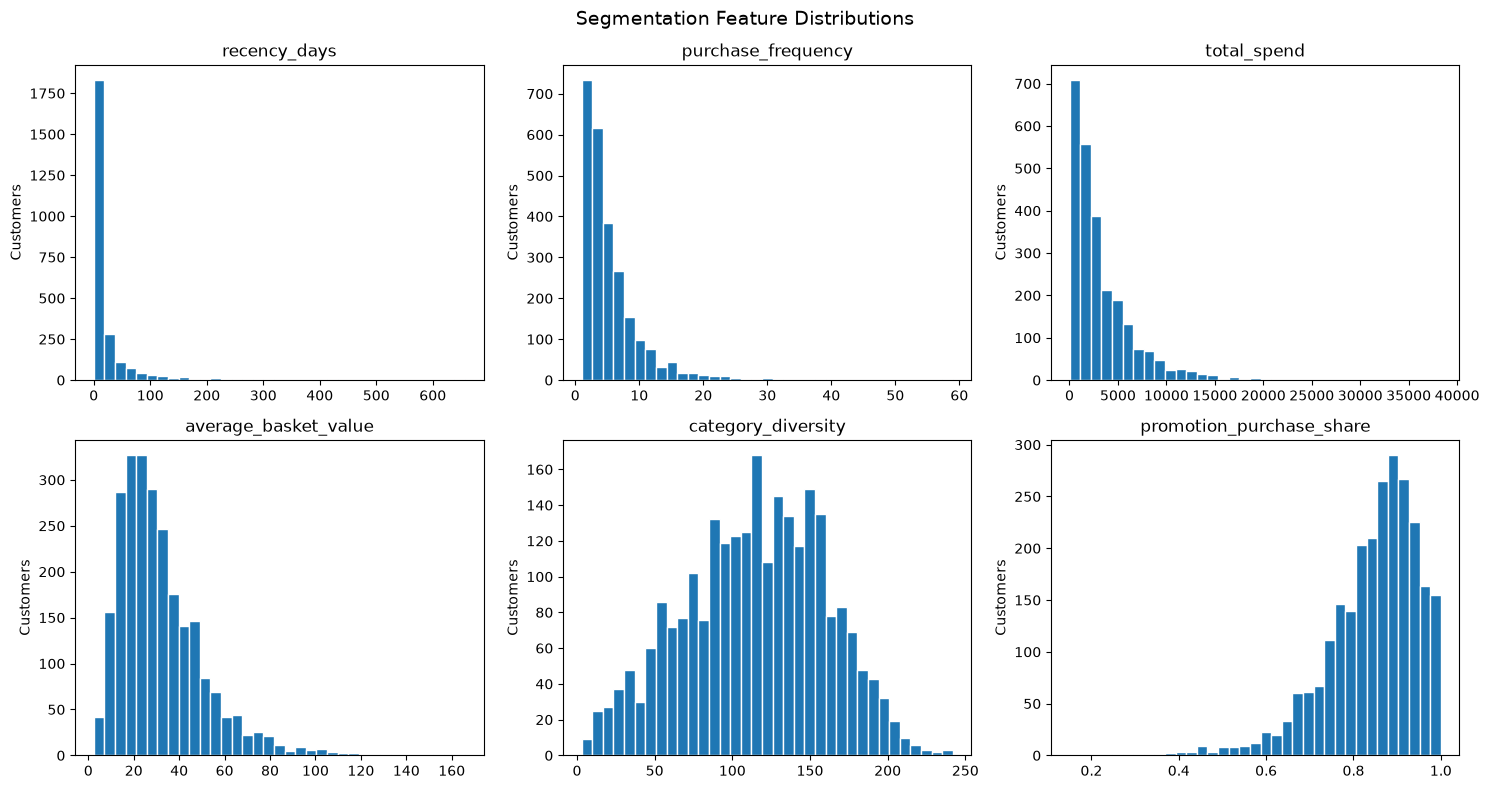

Saved figure: /Users/sudenazcaglar/Developer/fmcg-consumer-growth-insights/outputs/figures/07_segmentation_feature_distributions.png


In [5]:
# Purpose:
# Visually inspect feature shape and tail behavior before
# deciding on capping and transformation.

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8),
)

axes = axes.flatten()

for ax, feature in zip(
    axes,
    SEGMENT_FEATURES,
):
    values = (
        eligible_customers[feature]
        .astype(float)
    )

    ax.hist(
        values,
        bins=35,
        edgecolor="white",
    )

    ax.set_title(feature)
    ax.set_ylabel("Customers")

fig.suptitle(
    "Segmentation Feature Distributions",
    fontsize=14,
)

fig.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "07_segmentation_feature_distributions.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure: "
    f"{figure_path}"
)


## 5. Feature Association Diagnostic

Strongly associated features are not automatically removed because the project specifies six behavioral dimensions.

However, feature association is reviewed because K-Means distance can effectively give more weight to correlated behavioral dimensions.


In [6]:
spearman_matrix = (
    eligible_customers[
        SEGMENT_FEATURES
    ]
    .corr(method="spearman")
)

association_rows = []

for i, left in enumerate(
    SEGMENT_FEATURES
):
    for right in SEGMENT_FEATURES[
        i + 1:
    ]:
        correlation = (
            spearman_matrix.loc[
                left,
                right,
            ]
        )

        association_rows.append(
            {
                "feature_1": left,
                "feature_2": right,
                "spearman_correlation": (
                    correlation
                ),
                "absolute_correlation": abs(
                    correlation
                ),
            }
        )

feature_associations = (
    pd.DataFrame(
        association_rows
    )
    .sort_values(
        "absolute_correlation",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(spearman_matrix)
display(feature_associations.head(10))


,recency_days,purchase_frequency,total_spend,average_basket_value,category_diversity,promotion_purchase_share
recency_days,1.0000,-0.4978,-0.4870,-0.0243,-0.4459,0.0108
purchase_frequency,-0.4978,1.0000,0.7956,-0.0786,0.7310,-0.0851
total_spend,-0.4870,0.7956,1.0000,0.4518,0.9217,0.1993
average_basket_value,-0.0243,-0.0786,0.4518,1.0000,0.4229,0.5062
category_diversity,-0.4459,0.7310,0.9217,0.4229,1.0000,0.1737
promotion_purchase_share,0.0108,-0.0851,0.1993,0.5062,0.1737,1.0000


,feature_1,feature_2,spearman_correlation,absolute_correlation
0,total_spend,category_diversity,0.9217,0.9217
1,purchase_frequency,total_spend,0.7956,0.7956
2,purchase_frequency,category_diversity,0.7310,0.7310
3,average_basket_value,promotion_purchase_share,0.5062,0.5062
4,recency_days,purchase_frequency,-0.4978,0.4978
5,recency_days,total_spend,-0.4870,0.4870
6,total_spend,average_basket_value,0.4518,0.4518
7,recency_days,category_diversity,-0.4459,0.4459
8,average_basket_value,category_diversity,0.4229,0.4229
9,total_spend,promotion_purchase_share,0.1993,0.1993


## 6. Preprocessing Decision Audit

Preprocessing decisions will be recorded only after the diagnostics above are reviewed.

For each feature we will explicitly decide:

- whether 1st/99th percentile capping is justified;
- whether `log1p` transformation is justified;
- whether the feature remains unchanged;
- why that decision was made.

`promotion_purchase_share` will not be log-transformed.

All final K-Means features will subsequently be standardized using `StandardScaler`.


In [7]:
tables_dir = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
)

tables_dir.mkdir(
    parents=True,
    exist_ok=True,
)

feature_diagnostics.to_csv(
    tables_dir
    / "07_segmentation_feature_diagnostics.csv",
    index=False,
)

spearman_matrix.to_csv(
    tables_dir
    / "07_segmentation_feature_spearman_matrix.csv"
)

feature_associations.to_csv(
    tables_dir
    / "07_segmentation_feature_associations.csv",
    index=False,
)

eligibility_summary.to_csv(
    tables_dir
    / "07_segmentation_eligibility.csv",
    index=False,
)

print("SEGMENTATION FEATURE DIAGNOSTICS")

print(
    feature_diagnostics[
        [
            "feature",
            "p01",
            "median",
            "p99",
            "maximum",
            "raw_skew",
            "log1p_skew",
            "range_expansion_vs_p01_p99",
        ]
    ].to_string(index=False)
)

print()
print("STRONGEST FEATURE ASSOCIATIONS")

print(
    feature_associations[
        [
            "feature_1",
            "feature_2",
            "spearman_correlation",
        ]
    ]
    .head(6)
    .to_string(index=False)
)


SEGMENTATION FEATURE DIAGNOSTICS
                 feature     p01     median         p99     maximum  raw_skew  log1p_skew  range_expansion_vs_p01_p99
            recency_days  0.0000     6.0000    317.0500    657.0000    5.5747      0.4777                      2.0722
      purchase_frequency  1.0762     3.9545     24.9587     59.0000    3.6023      0.7001                      2.4285
             total_spend 84.2067 2,157.7500 15,325.0248 38,319.7900    2.4072     -0.6079                      2.5138
    average_basket_value  6.2364    27.4700     99.6361    165.8293    1.7257     -0.1649                      1.7499
      category_diversity 14.0000   117.0000    207.0000    242.0000   -0.1450     -1.6893                      1.2383
promotion_purchase_share  0.5000     0.8656      1.0000      1.0000   -1.2559         NaN                      1.7000

STRONGEST FEATURE ASSOCIATIONS
           feature_1                feature_2  spearman_correlation
         total_spend       category_diver

## 7. Final Preprocessing Pipeline

The diagnostics support the following modelling decisions:

| Feature | P1/P99 capping | Transformation |
|---|---|---|
| `recency_days` | Yes | `log1p` |
| `purchase_frequency` | Yes | `log1p` |
| `total_spend` | Yes | `log1p` |
| `average_basket_value` | No | `log1p` |
| `category_diversity` | No | None |
| `promotion_purchase_share` | No | None |

Capping affects only the modelling copy of the data. Original business metrics remain unchanged.

The strong association between `total_spend` and `category_diversity` is retained as an explicit modelling limitation rather than resolved by dropping a required behavioral dimension.

All final modelling features are standardized with `StandardScaler`.


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42

PREPROCESSING_PLAN = {
    "recency_days": {
        "cap": True,
        "log1p": True,
    },
    "purchase_frequency": {
        "cap": True,
        "log1p": True,
    },
    "total_spend": {
        "cap": True,
        "log1p": True,
    },
    "average_basket_value": {
        "cap": False,
        "log1p": True,
    },
    "category_diversity": {
        "cap": False,
        "log1p": False,
    },
    "promotion_purchase_share": {
        "cap": False,
        "log1p": False,
    },
}

model_features = (
    eligible_customers[
        SEGMENT_FEATURES
    ]
    .astype(float)
    .copy()
)

preprocessing_audit = []

for feature in SEGMENT_FEATURES:
    original = model_features[feature].copy()

    cap_applied = (
        PREPROCESSING_PLAN[feature]["cap"]
    )

    log_applied = (
        PREPROCESSING_PLAN[feature]["log1p"]
    )

    p01 = original.quantile(0.01)
    p99 = original.quantile(0.99)

    if cap_applied:
        model_features[feature] = (
            model_features[feature]
            .clip(
                lower=p01,
                upper=p99,
            )
        )

    after_cap = model_features[feature].copy()

    capped_low = int(
        (original < p01).sum()
    ) if cap_applied else 0

    capped_high = int(
        (original > p99).sum()
    ) if cap_applied else 0

    if log_applied:
        if (
            model_features[feature] < 0
        ).any():
            raise ValueError(
                f"{feature} contains negative values "
                "and cannot use log1p."
            )

        model_features[feature] = np.log1p(
            model_features[feature]
        )

    preprocessing_audit.append(
        {
            "feature": feature,
            "cap_applied": cap_applied,
            "cap_lower": (
                p01 if cap_applied else np.nan
            ),
            "cap_upper": (
                p99 if cap_applied else np.nan
            ),
            "capped_low_rows": capped_low,
            "capped_high_rows": capped_high,
            "log1p_applied": log_applied,
            "raw_skew": original.skew(),
            "post_cap_skew": after_cap.skew(),
            "final_skew": (
                model_features[feature].skew()
            ),
        }
    )

preprocessing_audit = pd.DataFrame(
    preprocessing_audit
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    model_features[
        SEGMENT_FEATURES
    ]
)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=SEGMENT_FEATURES,
    index=eligible_customers.index,
)

assert np.isfinite(
    X_scaled.to_numpy()
).all()

assert np.allclose(
    X_scaled.mean(axis=0).to_numpy(),
    0,
    atol=1e-10,
)

print("PREPROCESSING AUDIT")

print(
    preprocessing_audit.to_string(
        index=False
    )
)


PREPROCESSING AUDIT
                 feature  cap_applied  cap_lower   cap_upper  capped_low_rows  capped_high_rows  log1p_applied  raw_skew  post_cap_skew  final_skew
            recency_days         True     0.0000    317.0500                0                25           True    5.5747         3.8313      0.4376
      purchase_frequency         True     1.0762     24.9587               25                25           True    3.6023         2.1070      0.5937
             total_spend         True    84.2067 15,325.0248               25                25           True    2.4072         1.7312     -0.5242
    average_basket_value        False        NaN         NaN                0                 0           True    1.7257         1.7257     -0.1649
      category_diversity        False        NaN         NaN                0                 0          False   -0.1450        -0.1450     -0.1450
promotion_purchase_share        False        NaN         NaN                0               

In [9]:
# Export the preprocessing audit.

preprocessing_audit.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "08_segmentation_preprocessing_audit.csv",
    index=False,
)

model_feature_summary = pd.DataFrame(
    {
        "feature": SEGMENT_FEATURES,
        "scaled_mean": [
            X_scaled[column].mean()
            for column in SEGMENT_FEATURES
        ],
        "scaled_std": [
            X_scaled[column].std(ddof=0)
            for column in SEGMENT_FEATURES
        ],
    }
)

model_feature_summary.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "08_segmentation_scaled_feature_check.csv",
    index=False,
)

display(model_feature_summary)


,feature,scaled_mean,scaled_std
0,recency_days,0.0000,1.0000
1,purchase_frequency,-0.0000,1.0000
2,total_spend,-0.0000,1.0000
3,average_basket_value,-0.0000,1.0000
4,category_diversity,-0.0000,1.0000
5,promotion_purchase_share,0.0000,1.0000


## 8. K-Means Candidate Evaluation

The initial candidate set is:

- `k = 3`
- `k = 4`
- `k = 5`

For every solution we evaluate:

- inertia;
- silhouette score;
- minimum and maximum cluster population share;
- the full cluster-size distribution;
- original-scale behavioral profiles.

A solution is invalid when any cluster contains less than 5% of eligible customers.

Model selection is not finalized from silhouette alone. Business interpretability of the original-scale cluster profiles is reviewed before selecting the final solution.


In [10]:
K_CANDIDATES = [3, 4, 5]

candidate_models = {}
candidate_labels = {}
candidate_results = []
candidate_size_tables = []
candidate_profiles = []

for k in K_CANDIDATES:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50,
    )

    labels = model.fit_predict(
        X_scaled
    )

    candidate_models[k] = model
    candidate_labels[k] = labels

    counts = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

    shares = counts / len(labels)

    silhouette = silhouette_score(
        X_scaled,
        labels,
    )

    minimum_share = shares.min()
    maximum_share = shares.max()

    valid_solution = (
        minimum_share >= 0.05
    )

    candidate_results.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette_score": silhouette,
            "minimum_cluster_share": (
                minimum_share
            ),
            "maximum_cluster_share": (
                maximum_share
            ),
            "valid_min_5pct_rule": (
                valid_solution
            ),
        }
    )

    size_table = pd.DataFrame(
        {
            "k": k,
            "cluster_id": counts.index,
            "customers": counts.values,
            "customer_share": shares.values,
        }
    )

    candidate_size_tables.append(
        size_table
    )

    profile_source = (
        eligible_customers.copy()
    )

    profile_source[
        "cluster_id"
    ] = labels

    profile = (
        profile_source
        .groupby(
            "cluster_id"
        )
        .agg(
            customers=(
                "customer_id",
                "size",
            ),
            total_revenue=(
                "total_spend",
                "sum",
            ),
            avg_total_spend=(
                "total_spend",
                "mean",
            ),
            median_total_spend=(
                "total_spend",
                "median",
            ),
            avg_purchase_frequency=(
                "purchase_frequency",
                "mean",
            ),
            avg_recency_days=(
                "recency_days",
                "mean",
            ),
            avg_basket_value=(
                "average_basket_value",
                "mean",
            ),
            avg_category_diversity=(
                "category_diversity",
                "mean",
            ),
            avg_promotion_purchase_share=(
                "promotion_purchase_share",
                "mean",
            ),
            avg_promotion_spend_share=(
                "promotion_spend_share",
                "mean",
            ),
        )
        .reset_index()
    )

    profile.insert(
        0,
        "k",
        k,
    )

    profile[
        "customer_share"
    ] = (
        profile["customers"]
        / len(profile_source)
    )

    profile[
        "revenue_share"
    ] = (
        profile["total_revenue"]
        / profile_source[
            "total_spend"
        ].sum()
    )

    candidate_profiles.append(
        profile
    )

candidate_results = (
    pd.DataFrame(
        candidate_results
    )
    .sort_values("k")
    .reset_index(drop=True)
)

candidate_sizes = pd.concat(
    candidate_size_tables,
    ignore_index=True,
)

candidate_profiles = pd.concat(
    candidate_profiles,
    ignore_index=True,
)

print("K-MEANS CANDIDATE RESULTS")

print(
    candidate_results.to_string(
        index=False
    )
)


K-MEANS CANDIDATE RESULTS
 k    inertia  silhouette_score  minimum_cluster_share  maximum_cluster_share  valid_min_5pct_rule
 3 8,137.8264            0.2352                 0.2364                 0.4028                 True
 4 7,033.9101            0.2304                 0.1552                 0.3260                 True
 5 6,218.5961            0.2138                 0.1064                 0.2732                 True


In [11]:
# Candidate cluster sizes.

print("CANDIDATE CLUSTER SIZES")

for k in K_CANDIDATES:
    print()
    print(f"k={k}")

    subset = candidate_sizes[
        candidate_sizes["k"] == k
    ].copy()

    subset[
        "customer_share"
    ] = (
        subset["customer_share"] * 100
    )

    print(
        subset.to_string(
            index=False,
            formatters={
                "customer_share": (
                    lambda x: f"{x:.2f}%"
                )
            },
        )
    )


CANDIDATE CLUSTER SIZES

k=3
 k  cluster_id  customers customer_share
 3           0        591         23.64%
 3           1       1007         40.28%
 3           2        902         36.08%

k=4
 k  cluster_id  customers customer_share
 4           0        563         22.52%
 4           1        388         15.52%
 4           2        734         29.36%
 4           3        815         32.60%

k=5
 k  cluster_id  customers customer_share
 5           0        683         27.32%
 5           1        574         22.96%
 5           2        528         21.12%
 5           3        449         17.96%
 5           4        266         10.64%


In [12]:
# Original-scale profiles used for interpretability review.

profile_display_columns = [
    "k",
    "cluster_id",
    "customers",
    "customer_share",
    "revenue_share",
    "avg_total_spend",
    "avg_purchase_frequency",
    "avg_recency_days",
    "avg_basket_value",
    "avg_category_diversity",
    "avg_promotion_purchase_share",
    "avg_promotion_spend_share",
]

print("CANDIDATE ORIGINAL-SCALE PROFILES")

for k in K_CANDIDATES:
    print()
    print(f"k={k}")

    subset = (
        candidate_profiles[
            candidate_profiles["k"] == k
        ][
            profile_display_columns
        ]
        .copy()
    )

    print(
        subset.to_string(
            index=False,
            formatters={
                "customer_share": (
                    lambda x: f"{x:.2%}"
                ),
                "revenue_share": (
                    lambda x: f"{x:.2%}"
                ),
                "avg_total_spend": (
                    lambda x: f"{x:,.2f}"
                ),
                "avg_purchase_frequency": (
                    lambda x: f"{x:.2f}"
                ),
                "avg_recency_days": (
                    lambda x: f"{x:.2f}"
                ),
                "avg_basket_value": (
                    lambda x: f"{x:.2f}"
                ),
                "avg_category_diversity": (
                    lambda x: f"{x:.2f}"
                ),
                "avg_promotion_purchase_share": (
                    lambda x: f"{x:.2%}"
                ),
                "avg_promotion_spend_share": (
                    lambda x: f"{x:.2%}"
                ),
            },
        )
    )


CANDIDATE ORIGINAL-SCALE PROFILES

k=3
 k  cluster_id  customers customer_share revenue_share avg_total_spend avg_purchase_frequency avg_recency_days avg_basket_value avg_category_diversity avg_promotion_purchase_share avg_promotion_spend_share
 3           0        591         23.64%         4.99%          680.91                   3.14            52.97            16.29                  62.26                       74.69%                    46.35%
 3           1       1007         40.28%        73.52%        5,882.46                   9.17             5.32            33.22                 153.60                       85.37%                    51.21%
 3           2        902         36.08%        21.49%        1,919.49                   2.94            30.24            40.07                 105.41                       89.94%                    51.36%

k=4
 k  cluster_id  customers customer_share revenue_share avg_total_spend avg_purchase_frequency avg_recency_days avg_basket_value avg_

In [13]:
# Export candidate model diagnostics.

candidate_results.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "09_kmeans_candidate_results.csv",
    index=False,
)

candidate_sizes.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "09_kmeans_candidate_cluster_sizes.csv",
    index=False,
)

candidate_profiles.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "09_kmeans_candidate_profiles.csv",
    index=False,
)

print(
    "Candidate diagnostics exported."
)


Candidate diagnostics exported.


## 9. Final Model Selection and Detailed Profiling

### Selected solution: `k = 3`

All three candidate solutions satisfy the minimum 5% cluster-size rule.

The final selection is `k = 3` because:

- it has the highest silhouette score: **0.2352**;
- `k = 4` has a silhouette score of **0.2304**, only 0.0048 lower, which is within the specification's `<0.02` equivalence threshold;
- when performance is effectively equivalent, the simpler interpretable solution is preferred;
- `k = 5` has a lower silhouette score of **0.2138**, 0.0214 below `k = 3`, while introducing additional fragmentation.

The fall in inertia as `k` increases is expected and is not treated as sufficient evidence to prefer a more complex solution.

Raw K-Means cluster IDs remain temporary at this stage. Business-readable segment names and final segment IDs will be assigned only after complete original-scale and category profiling.


In [14]:
FINAL_K = 3

final_labels = candidate_labels[
    FINAL_K
].copy()

final_cluster_assignments = (
    eligible_customers[
        ["customer_id"]
    ]
    .copy()
)

final_cluster_assignments[
    "cluster_id"
] = final_labels

assert (
    len(final_cluster_assignments)
    == len(eligible_customers)
)

assert (
    final_cluster_assignments[
        "customer_id"
    ]
    .duplicated()
    .sum()
    == 0
)

assert (
    final_cluster_assignments[
        "cluster_id"
    ]
    .nunique()
    == FINAL_K
)

print("FINAL MODEL SELECTION")
print(f"Selected k: {FINAL_K}")
print(
    "Silhouette score: "
    f"{candidate_results.loc[candidate_results['k'] == FINAL_K, 'silhouette_score'].iloc[0]:.4f}"
)
print(
    "Eligible customers assigned: "
    f"{len(final_cluster_assignments):,}"
)
print(
    "Customers without assignment: "
    f"{final_cluster_assignments['cluster_id'].isna().sum()}"
)


FINAL MODEL SELECTION
Selected k: 3
Silhouette score: 0.2352
Eligible customers assigned: 2,500
Customers without assignment: 0


In [15]:
# Recompute the final profile directly from original-scale metrics.

final_profile_source = (
    eligible_customers
    .merge(
        final_cluster_assignments,
        on="customer_id",
        how="inner",
        validate="one_to_one",
    )
)

final_cluster_profile = (
    final_profile_source
    .groupby(
        "cluster_id"
    )
    .agg(
        customers=(
            "customer_id",
            "size",
        ),
        total_revenue=(
            "total_spend",
            "sum",
        ),
        average_customer_spend=(
            "total_spend",
            "mean",
        ),
        median_customer_spend=(
            "total_spend",
            "median",
        ),
        purchase_frequency=(
            "purchase_frequency",
            "mean",
        ),
        recency_days=(
            "recency_days",
            "mean",
        ),
        average_basket_value=(
            "average_basket_value",
            "mean",
        ),
        category_diversity=(
            "category_diversity",
            "mean",
        ),
        promotion_purchase_share=(
            "promotion_purchase_share",
            "mean",
        ),
        promotion_spend_share=(
            "promotion_spend_share",
            "mean",
        ),
    )
    .reset_index()
)

final_cluster_profile[
    "customer_base_share"
] = (
    final_cluster_profile["customers"]
    / len(final_profile_source)
)

final_cluster_profile[
    "revenue_share"
] = (
    final_cluster_profile["total_revenue"]
    / final_profile_source[
        "total_spend"
    ].sum()
)

assert (
    final_cluster_profile[
        "customers"
    ].sum()
    == len(eligible_customers)
)

assert np.isclose(
    final_cluster_profile[
        "total_revenue"
    ].sum(),
    eligible_customers[
        "total_spend"
    ].sum(),
    atol=0.01,
)

display(final_cluster_profile)


,cluster_id,customers,total_revenue,average_customer_spend,median_customer_spend,purchase_frequency,recency_days,average_basket_value,category_diversity,promotion_purchase_share,promotion_spend_share,customer_base_share,revenue_share
0,0,591,"402,418.5100",680.9112,552.1800,3.1439,52.9746,16.2897,62.2555,0.7469,0.4635,0.2364,0.0499
1,1,1007,"5,923,641.6500","5,882.4644","4,923.1600",9.1676,5.3227,33.2219,153.5978,0.8537,0.5121,0.4028,0.7352
2,2,902,"1,731,383.6400","1,919.4941","1,669.4050",2.9431,30.2350,40.0704,105.4124,0.8994,0.5136,0.3608,0.2149


In [16]:
# Compare each cluster with the overall eligible-customer mean.
# Index = 100 means equal to the overall population mean.

benchmark_metrics = [
    "total_spend",
    "purchase_frequency",
    "recency_days",
    "average_basket_value",
    "category_diversity",
    "promotion_purchase_share",
    "promotion_spend_share",
]

overall_means = (
    final_profile_source[
        benchmark_metrics
    ]
    .mean()
)

cluster_means = (
    final_profile_source
    .groupby("cluster_id")[
        benchmark_metrics
    ]
    .mean()
)

relative_profile_index = (
    cluster_means
    .divide(
        overall_means,
        axis="columns",
    )
    * 100
)

relative_profile_index = (
    relative_profile_index
    .reset_index()
)

display(relative_profile_index)


,cluster_id,total_spend,purchase_frequency,recency_days,average_basket_value,category_diversity,promotion_purchase_share,promotion_spend_share
0,0,21.1268,57.1837,207.1263,51.4032,54.3151,88.3972,92.4870
1,1,182.5165,166.7504,20.8115,104.8339,134.0071,101.0389,102.1844
2,2,59.5565,53.5330,118.2164,126.4445,91.9675,106.4424,102.4840


## 10. Important Categories by Final Cluster

Category importance is evaluated on original business metrics.

For each raw cluster we calculate:

- aggregate category sales;
- category share of cluster sales;
- number of customers purchasing the category;
- customer penetration within the cluster;
- category transaction count.

Categories are ranked deterministically by:

1. category sales descending;
2. category transactions descending;
3. category name ascending.

The top five categories are retained for interpretation.


In [17]:
category_profile_source = (
    customer_category_metrics
    .merge(
        final_cluster_assignments,
        on="customer_id",
        how="inner",
        validate="many_to_one",
    )
    .copy()
)

for column in [
    "category_spend",
    "category_transactions",
]:
    category_profile_source[column] = (
        pd.to_numeric(
            category_profile_source[column],
            errors="coerce",
        )
    )

assert (
    category_profile_source[
        [
            "category_spend",
            "category_transactions",
        ]
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

segment_category_profile = (
    category_profile_source
    .groupby(
        [
            "cluster_id",
            "category",
        ],
        as_index=False,
    )
    .agg(
        category_spend=(
            "category_spend",
            "sum",
        ),
        category_transactions=(
            "category_transactions",
            "sum",
        ),
        purchasing_customers=(
            "customer_id",
            "nunique",
        ),
    )
)

segment_totals = (
    final_cluster_profile[
        [
            "cluster_id",
            "customers",
            "total_revenue",
        ]
    ]
    .rename(
        columns={
            "customers": "segment_customers",
            "total_revenue": "segment_revenue",
        }
    )
)

segment_category_profile = (
    segment_category_profile
    .merge(
        segment_totals,
        on="cluster_id",
        how="left",
        validate="many_to_one",
    )
)

segment_category_profile[
    "category_revenue_share"
] = (
    segment_category_profile[
        "category_spend"
    ]
    / segment_category_profile[
        "segment_revenue"
    ]
)

segment_category_profile[
    "customer_penetration"
] = (
    segment_category_profile[
        "purchasing_customers"
    ]
    / segment_category_profile[
        "segment_customers"
    ]
)

segment_category_profile = (
    segment_category_profile
    .sort_values(
        [
            "cluster_id",
            "category_spend",
            "category_transactions",
            "category",
        ],
        ascending=[
            True,
            False,
            False,
            True,
        ],
    )
)

segment_category_profile[
    "category_rank"
] = (
    segment_category_profile
    .groupby(
        "cluster_id"
    )
    .cumcount()
    + 1
)

top_segment_categories = (
    segment_category_profile[
        segment_category_profile[
            "category_rank"
        ] <= 5
    ]
    .copy()
)

# Reconcile segment category revenue to customer-level revenue.
category_reconciliation = (
    segment_category_profile
    .groupby(
        "cluster_id",
        as_index=False,
    )
    .agg(
        category_revenue=(
            "category_spend",
            "sum",
        )
    )
    .merge(
        final_cluster_profile[
            [
                "cluster_id",
                "total_revenue",
            ]
        ],
        on="cluster_id",
        how="left",
        validate="one_to_one",
    )
)

category_reconciliation[
    "difference"
] = (
    category_reconciliation[
        "category_revenue"
    ]
    - category_reconciliation[
        "total_revenue"
    ]
)

assert (
    category_reconciliation[
        "difference"
    ].abs().max()
    <= 0.01
)

display(top_segment_categories)


,cluster_id,category,category_spend,category_transactions,purchasing_customers,segment_customers,segment_revenue,category_revenue_share,customer_penetration,category_rank
75,0,COUPON/MISC ITEMS,"21,964.8500",1337,326,591,"402,418.5100",0.0546,0.5516,1
261,0,SOFT DRINKS,"20,450.2600",5791,517,591,"402,418.5100",0.0508,0.8748,2
24,0,BEEF,"14,073.4500",2064,427,591,"402,418.5100",0.0350,0.7225,3
25,0,BEERS/ALES,"13,390.4000",1675,258,591,"402,418.5100",0.0333,0.4365,4
120,0,FLUID MILK PRODUCTS,"11,733.8600",4708,527,591,"402,418.5100",0.0292,0.8917,5
372,1,COUPON/MISC ITEMS,"542,555.4200",22630,968,1007,"5,923,641.6500",0.0916,0.9613,1
564,1,SOFT DRINKS,"237,213.6300",52543,1004,1007,"5,923,641.6500",0.0400,0.9970,2
319,1,BEEF,"221,253.6700",26166,980,1007,"5,923,641.6500",0.0374,0.9732,3
417,1,FLUID MILK PRODUCTS,"149,879.7000",49425,1005,1007,"5,923,641.6500",0.0253,0.9980,4
346,1,CHEESE,"135,886.4000",33676,1005,1007,"5,923,641.6500",0.0229,0.9980,5


In [18]:
# Export final pre-naming profiles.

final_cluster_profile.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "10_final_k3_cluster_profile.csv",
    index=False,
)

relative_profile_index.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "10_final_k3_relative_profile_index.csv",
    index=False,
)

segment_category_profile.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "10_final_k3_category_profile.csv",
    index=False,
)

top_segment_categories.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "10_final_k3_top_categories.csv",
    index=False,
)

final_cluster_assignments.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "10_final_k3_raw_assignments.csv",
    index=False,
)

print("FINAL K=3 PROFILE")

profile_print = (
    final_cluster_profile[
        [
            "cluster_id",
            "customers",
            "customer_base_share",
            "revenue_share",
            "average_customer_spend",
            "purchase_frequency",
            "recency_days",
            "average_basket_value",
            "category_diversity",
            "promotion_purchase_share",
            "promotion_spend_share",
        ]
    ]
    .copy()
)

print(
    profile_print.to_string(
        index=False,
        formatters={
            "customer_base_share": (
                lambda x: f"{x:.2%}"
            ),
            "revenue_share": (
                lambda x: f"{x:.2%}"
            ),
            "average_customer_spend": (
                lambda x: f"{x:,.2f}"
            ),
            "purchase_frequency": (
                lambda x: f"{x:.2f}"
            ),
            "recency_days": (
                lambda x: f"{x:.2f}"
            ),
            "average_basket_value": (
                lambda x: f"{x:.2f}"
            ),
            "category_diversity": (
                lambda x: f"{x:.2f}"
            ),
            "promotion_purchase_share": (
                lambda x: f"{x:.2%}"
            ),
            "promotion_spend_share": (
                lambda x: f"{x:.2%}"
            ),
        },
    )
)

print()
print(
    "RELATIVE PROFILE INDEX "
    "(OVERALL MEAN = 100)"
)

print(
    relative_profile_index.to_string(
        index=False,
        float_format=lambda x: f"{x:.1f}",
    )
)

print()
print("TOP CATEGORIES BY FINAL CLUSTER")

for cluster_id in sorted(
    top_segment_categories[
        "cluster_id"
    ].unique()
):
    print()
    print(
        f"Raw cluster {cluster_id}"
    )

    subset = (
        top_segment_categories[
            top_segment_categories[
                "cluster_id"
            ] == cluster_id
        ][
            [
                "category_rank",
                "category",
                "category_spend",
                "category_revenue_share",
                "customer_penetration",
            ]
        ]
        .copy()
    )

    print(
        subset.to_string(
            index=False,
            formatters={
                "category_spend": (
                    lambda x: f"{x:,.2f}"
                ),
                "category_revenue_share": (
                    lambda x: f"{x:.2%}"
                ),
                "customer_penetration": (
                    lambda x: f"{x:.2%}"
                ),
            },
        )
    )

print()
print("CATEGORY RECONCILIATION")
print(
    category_reconciliation.to_string(
        index=False
    )
)


FINAL K=3 PROFILE
 cluster_id  customers customer_base_share revenue_share average_customer_spend purchase_frequency recency_days average_basket_value category_diversity promotion_purchase_share promotion_spend_share
          0        591              23.64%         4.99%                 680.91               3.14        52.97                16.29              62.26                   74.69%                46.35%
          1       1007              40.28%        73.52%               5,882.46               9.17         5.32                33.22             153.60                   85.37%                51.21%
          2        902              36.08%        21.49%               1,919.49               2.94        30.24                40.07             105.41                   89.94%                51.36%

RELATIVE PROFILE INDEX (OVERALL MEAN = 100)
 cluster_id  total_spend  purchase_frequency  recency_days  average_basket_value  category_diversity  promotion_purchase_share  promotion_spe

## 11. Business Segment Naming

The final `k = 3` clusters are translated into business-readable behavioral segments only after reviewing the complete original-scale profiles.

### Segment 1 — High-Value Frequent Shoppers

This segment combines:

- the highest average customer sales;
- the highest purchase frequency;
- the lowest recency;
- the broadest category portfolio.

It represents the core high-engagement, high-value customer group.

### Segment 2 — Large-Basket Occasional Shoppers

This segment combines:

- relatively low purchase frequency;
- the highest average basket value;
- mid-range historical customer value;
- high promotional-basket exposure.

Its value pattern is driven more by larger purchase occasions than by frequent shopping.

### Segment 3 — Low-Value Low-Engagement Shoppers

This segment combines:

- the lowest historical customer sales;
- the highest recency;
- the lowest average basket value;
- the narrowest category portfolio.

The label is descriptive of observed behavior only and does not imply permanent inactivity or churn.

Category composition is broadly similar across segments and therefore is not used as the primary naming dimension. `COUPON/MISC ITEMS` is retained as a source category in profiling but is not treated as a strategic merchandise category for naming.


In [19]:
# Assign semantic roles from the observed profile rather than
# relying on arbitrary raw K-Means label numbers.

profile_indexed = (
    final_cluster_profile
    .set_index("cluster_id")
)

high_value_cluster = int(
    profile_indexed[
        "average_customer_spend"
    ].idxmax()
)

remaining_clusters = [
    int(cluster_id)
    for cluster_id
    in profile_indexed.index
    if int(cluster_id)
    != high_value_cluster
]

low_engagement_cluster = int(
    profile_indexed.loc[
        remaining_clusters,
        "recency_days",
    ].idxmax()
)

large_basket_cluster = next(
    cluster_id
    for cluster_id
    in remaining_clusters
    if cluster_id
    != low_engagement_cluster
)

segment_definition = pd.DataFrame(
    [
        {
            "cluster_id": high_value_cluster,
            "segment_id": 1,
            "segment_name": (
                "High-Value Frequent Shoppers"
            ),
        },
        {
            "cluster_id": large_basket_cluster,
            "segment_id": 2,
            "segment_name": (
                "Large-Basket Occasional Shoppers"
            ),
        },
        {
            "cluster_id": low_engagement_cluster,
            "segment_id": 3,
            "segment_name": (
                "Low-Value Low-Engagement Shoppers"
            ),
        },
    ]
)

assert (
    segment_definition[
        "cluster_id"
    ].nunique()
    == FINAL_K
)

assert (
    segment_definition[
        "segment_id"
    ].nunique()
    == FINAL_K
)

# Guardrails ensuring the names still match the observed profile.
assert (
    profile_indexed.loc[
        high_value_cluster,
        "average_customer_spend",
    ]
    == profile_indexed[
        "average_customer_spend"
    ].max()
)

assert (
    profile_indexed.loc[
        high_value_cluster,
        "purchase_frequency",
    ]
    == profile_indexed[
        "purchase_frequency"
    ].max()
)

assert (
    profile_indexed.loc[
        low_engagement_cluster,
        "recency_days",
    ]
    == profile_indexed.loc[
        remaining_clusters,
        "recency_days",
    ].max()
)

assert (
    profile_indexed.loc[
        large_basket_cluster,
        "average_basket_value",
    ]
    > eligible_customers[
        "average_basket_value"
    ].mean()
)

print("SEGMENT DEFINITION")
print(
    segment_definition.to_string(
        index=False
    )
)


SEGMENT DEFINITION
 cluster_id  segment_id                      segment_name
          1           1      High-Value Frequent Shoppers
          2           2  Large-Basket Occasional Shoppers
          0           3 Low-Value Low-Engagement Shoppers


In [20]:
final_segment_assignments = (
    final_cluster_assignments
    .merge(
        segment_definition,
        on="cluster_id",
        how="left",
        validate="many_to_one",
    )
)

assert (
    final_segment_assignments[
        "segment_name"
    ].isna().sum()
    == 0
)

assert (
    len(final_segment_assignments)
    == len(eligible_customers)
)

assert (
    final_segment_assignments[
        "customer_id"
    ].nunique()
    == len(eligible_customers)
)

named_segment_profile = (
    final_cluster_profile
    .merge(
        segment_definition,
        on="cluster_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values("segment_id")
    .reset_index(drop=True)
)

named_top_categories = (
    top_segment_categories
    .merge(
        segment_definition,
        on="cluster_id",
        how="left",
        validate="many_to_one",
    )
    .sort_values(
        [
            "segment_id",
            "category_rank",
        ]
    )
    .reset_index(drop=True)
)

display(named_segment_profile)


,cluster_id,customers,total_revenue,average_customer_spend,median_customer_spend,purchase_frequency,recency_days,average_basket_value,category_diversity,promotion_purchase_share,promotion_spend_share,customer_base_share,revenue_share,segment_id,segment_name
0,1,1007,"5,923,641.6500","5,882.4644","4,923.1600",9.1676,5.3227,33.2219,153.5978,0.8537,0.5121,0.4028,0.7352,1,High-Value Frequent Shoppers
1,2,902,"1,731,383.6400","1,919.4941","1,669.4050",2.9431,30.2350,40.0704,105.4124,0.8994,0.5136,0.3608,0.2149,2,Large-Basket Occasional Shoppers
2,0,591,"402,418.5100",680.9112,552.1800,3.1439,52.9746,16.2897,62.2555,0.7469,0.4635,0.2364,0.0499,3,Low-Value Low-Engagement Shoppers


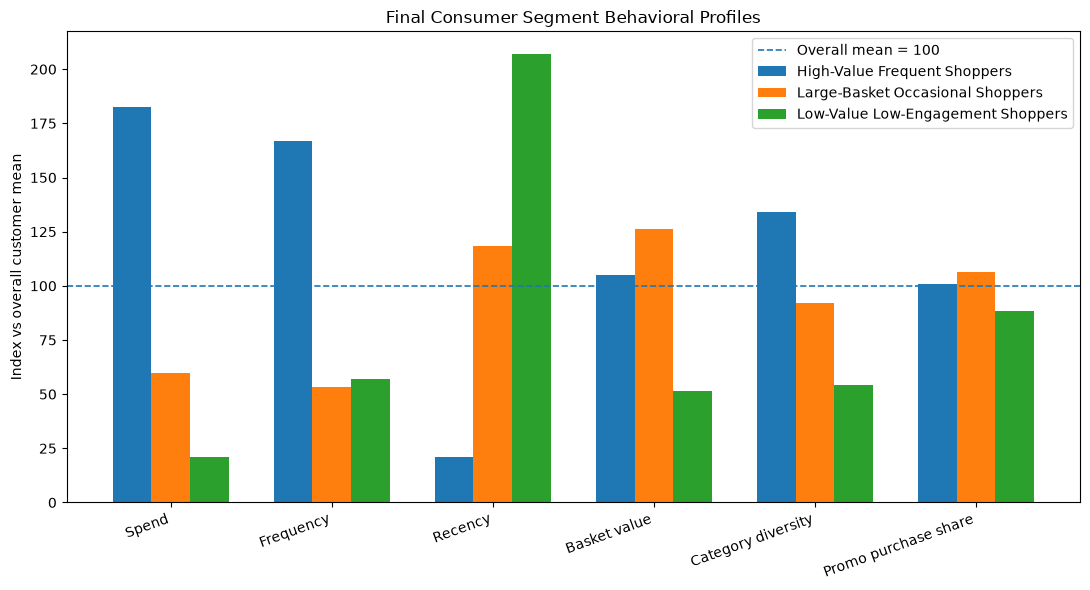

Saved figure: /Users/sudenazcaglar/Developer/fmcg-consumer-growth-insights/outputs/figures/08_final_segment_profile_index.png


In [21]:
# Create a concise relative-index profile chart.
# Overall eligible-customer mean = 100.

named_relative_profile = (
    relative_profile_index
    .merge(
        segment_definition,
        on="cluster_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values("segment_id")
)

plot_metrics = [
    "total_spend",
    "purchase_frequency",
    "recency_days",
    "average_basket_value",
    "category_diversity",
    "promotion_purchase_share",
]

plot_labels = [
    "Spend",
    "Frequency",
    "Recency",
    "Basket value",
    "Category diversity",
    "Promo purchase share",
]

x = np.arange(
    len(plot_metrics)
)

width = 0.24

fig, ax = plt.subplots(
    figsize=(11, 6)
)

for i, row in enumerate(
    named_relative_profile.itertuples(
        index=False
    )
):
    values = [
        getattr(row, metric)
        for metric in plot_metrics
    ]

    ax.bar(
        x + (i - 1) * width,
        values,
        width=width,
        label=row.segment_name,
    )

ax.axhline(
    100,
    linestyle="--",
    linewidth=1.2,
    label="Overall mean = 100",
)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_labels,
    rotation=20,
    ha="right",
)

ax.set_ylabel(
    "Index vs overall customer mean"
)

ax.set_title(
    "Final Consumer Segment Behavioral Profiles"
)

ax.legend()

fig.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "08_final_segment_profile_index.png"
)

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure: "
    f"{figure_path}"
)


## 12. PostgreSQL Segment Output

The final assignment is written to:

`analytics.customer_segments`

Required business fields are:

- `customer_id`
- `segment_id`
- `segment_name`

A reproducibility field, `model_version`, is also stored.

Every eligible customer must have exactly one assignment.


In [22]:
segment_output = (
    final_segment_assignments[
        [
            "customer_id",
            "segment_id",
            "segment_name",
        ]
    ]
    .copy()
)

segment_output[
    "model_version"
] = "kmeans_k3_v1"

with engine.begin() as connection:
    connection.execute(
        text(
            '''
            DROP TABLE IF EXISTS
                analytics.customer_segments;

            CREATE TABLE
                analytics.customer_segments
            (
                customer_id BIGINT PRIMARY KEY,
                segment_id INTEGER NOT NULL,
                segment_name TEXT NOT NULL,
                model_version TEXT NOT NULL,
                created_at TIMESTAMPTZ
                    NOT NULL
                    DEFAULT CURRENT_TIMESTAMP,
                CONSTRAINT
                    customer_segments_segment_id_chk
                    CHECK (
                        segment_id BETWEEN 1 AND 3
                    )
            );
            '''
        )
    )

    segment_output.to_sql(
        name="customer_segments",
        con=connection,
        schema="analytics",
        if_exists="append",
        index=False,
        method="multi",
    )

print(
    "PostgreSQL write: "
    "analytics.customer_segments"
)


PostgreSQL write: analytics.customer_segments


In [23]:
# Validate persisted segmentation output.

database_segment_summary = pd.read_sql_query(
    text(
        '''
        SELECT
            COUNT(*) AS rows,
            COUNT(DISTINCT customer_id)
                AS distinct_customers,
            COUNT(DISTINCT segment_id)
                AS distinct_segments,
            COUNT(*) FILTER (
                WHERE segment_name IS NULL
            ) AS null_segment_names
        FROM analytics.customer_segments
        '''
    ),
    engine,
)

unassigned_check = pd.read_sql_query(
    text(
        '''
        SELECT COUNT(*) AS customers_without_segment
        FROM analytics.customer_metrics cm
        LEFT JOIN analytics.customer_segments cs
            ON cm.customer_id = cs.customer_id
        WHERE cs.customer_id IS NULL
          AND cm.total_spend > 0
          AND cm.total_transactions > 0
        '''
    ),
    engine,
)

database_profile = pd.read_sql_query(
    text(
        '''
        SELECT
            cs.segment_id,
            cs.segment_name,
            COUNT(*) AS customers,
            SUM(cm.total_spend) AS total_revenue,
            AVG(cm.total_spend)
                AS average_customer_spend,
            AVG(cm.purchase_frequency)
                AS purchase_frequency,
            AVG(cm.recency_days)
                AS recency_days,
            AVG(cm.average_basket_value)
                AS average_basket_value,
            AVG(cm.category_diversity)
                AS category_diversity,
            AVG(cm.promotion_purchase_share)
                AS promotion_purchase_share,
            AVG(cm.promotion_spend_share)
                AS promotion_spend_share
        FROM analytics.customer_segments cs
        JOIN analytics.customer_metrics cm
            ON cs.customer_id = cm.customer_id
        GROUP BY
            cs.segment_id,
            cs.segment_name
        ORDER BY
            cs.segment_id
        '''
    ),
    engine,
)

for column in [
    "total_revenue",
    "average_customer_spend",
    "purchase_frequency",
    "recency_days",
    "average_basket_value",
    "category_diversity",
    "promotion_purchase_share",
    "promotion_spend_share",
]:
    database_profile[column] = pd.to_numeric(
        database_profile[column],
        errors="raise",
    )

assert (
    int(
        database_segment_summary.loc[
            0,
            "rows",
        ]
    )
    == len(eligible_customers)
)

assert (
    int(
        database_segment_summary.loc[
            0,
            "distinct_customers",
        ]
    )
    == len(eligible_customers)
)

assert (
    int(
        database_segment_summary.loc[
            0,
            "distinct_segments",
        ]
    )
    == FINAL_K
)

assert (
    int(
        database_segment_summary.loc[
            0,
            "null_segment_names",
        ]
    )
    == 0
)

assert (
    int(
        unassigned_check.loc[
            0,
            "customers_without_segment",
        ]
    )
    == 0
)

assert np.isclose(
    database_profile[
        "total_revenue"
    ].sum(),
    eligible_customers[
        "total_spend"
    ].sum(),
    atol=0.01,
)

print("POSTGRESQL SEGMENT VALIDATION")
print(
    database_segment_summary.to_string(
        index=False
    )
)
print(
    unassigned_check.to_string(
        index=False
    )
)
print()
print(
    database_profile.to_string(
        index=False
    )
)


POSTGRESQL SEGMENT VALIDATION
 rows  distinct_customers  distinct_segments  null_segment_names
 2500                2500                  3                   0
 customers_without_segment
                         0

 segment_id                      segment_name  customers  total_revenue  average_customer_spend  purchase_frequency  recency_days  average_basket_value  category_diversity  promotion_purchase_share  promotion_spend_share
          1      High-Value Frequent Shoppers       1007 5,923,641.6500              5,882.4644              9.1676        5.3227               33.2219            153.5978                    0.8537                 0.5121
          2  Large-Basket Occasional Shoppers        902 1,731,383.6400              1,919.4941              2.9431       30.2350               40.0704            105.4124                    0.8994                 0.5136
          3 Low-Value Low-Engagement Shoppers        591   402,418.5100                680.9112              3.1439       

In [24]:
# Export final named segmentation artifacts.

named_segment_profile.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "11_final_segment_profile.csv",
    index=False,
)

named_top_categories.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "11_final_segment_top_categories.csv",
    index=False,
)

segment_output.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "11_customer_segments.csv",
    index=False,
)

print("FINAL SEGMENT SUMMARY")

summary = (
    named_segment_profile[
        [
            "segment_id",
            "segment_name",
            "customers",
            "customer_base_share",
            "revenue_share",
            "average_customer_spend",
            "purchase_frequency",
            "recency_days",
            "average_basket_value",
            "category_diversity",
            "promotion_purchase_share",
            "promotion_spend_share",
        ]
    ]
    .copy()
)

print(
    summary.to_string(
        index=False,
        formatters={
            "customer_base_share": (
                lambda x: f"{x:.2%}"
            ),
            "revenue_share": (
                lambda x: f"{x:.2%}"
            ),
            "average_customer_spend": (
                lambda x: f"{x:,.2f}"
            ),
            "purchase_frequency": (
                lambda x: f"{x:.2f}"
            ),
            "recency_days": (
                lambda x: f"{x:.2f}"
            ),
            "average_basket_value": (
                lambda x: f"{x:.2f}"
            ),
            "category_diversity": (
                lambda x: f"{x:.2f}"
            ),
            "promotion_purchase_share": (
                lambda x: f"{x:.2%}"
            ),
            "promotion_spend_share": (
                lambda x: f"{x:.2%}"
            ),
        },
    )
)


FINAL SEGMENT SUMMARY
 segment_id                      segment_name  customers customer_base_share revenue_share average_customer_spend purchase_frequency recency_days average_basket_value category_diversity promotion_purchase_share promotion_spend_share
          1      High-Value Frequent Shoppers       1007              40.28%        73.52%               5,882.46               9.17         5.32                33.22             153.60                   85.37%                51.21%
          2  Large-Basket Occasional Shoppers        902              36.08%        21.49%               1,919.49               2.94        30.24                40.07             105.41                   89.94%                51.36%
          3 Low-Value Low-Engagement Shoppers        591              23.64%         4.99%                 680.91               3.14        52.97                16.29              62.26                   74.69%                46.35%


## 13. Segmentation Limitations

- K-Means imposes Euclidean distance and roughly centroid-based cluster geometry.
- Silhouette performance is moderate rather than exceptionally high, so the segments should be interpreted as useful behavioral summaries rather than naturally isolated customer classes.
- `total_spend` and `category_diversity` are strongly associated; because both are required behavioral dimensions, their overlap remains a modelling limitation.
- Capping and transformations are applied only to modelling inputs. Business-facing profiles use uncapped original values.
- Recency is measured relative to the end of the observed dataset, not the current date.
- Segment labels describe observed behavior and do not imply causality, profitability or permanent customer state.
